# AAI614: Data Science & its Applications

*Notebook 5.4: Experiment with KNN*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%205/Notebook5.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Example I: Classifying Social Networks Ads

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

dataset = pd.read_csv('https://raw.githubusercontent.com/harmanani/AAI614/main/Week%205/Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

## Splitting the dataset into the Training set and Test set

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


## Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Fitting K-NN to the Training set

Use the KNN model for training by specifying the input and output variables of the training set as follows.  Note that *p =2* refers to **euclidean distance**.

In [5]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

## Predicting the Test set results

In [6]:
y_pred = classifier.predict(X_test)

## Making the Confusion Matrix

In [7]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[64,  4],
       [ 3, 29]])

# Example II: Classifying Digits

In [8]:
from sklearn import metrics

In [9]:
from sklearn.datasets import load_digits
digits = load_digits()
# Train the model using the training sets
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25)

In [10]:
digits = load_digits()
# Train the model using the training sets
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25)

In [11]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [12]:
#Predict Output
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model.predict(x_test))
score = model.score(x_test, y_test)

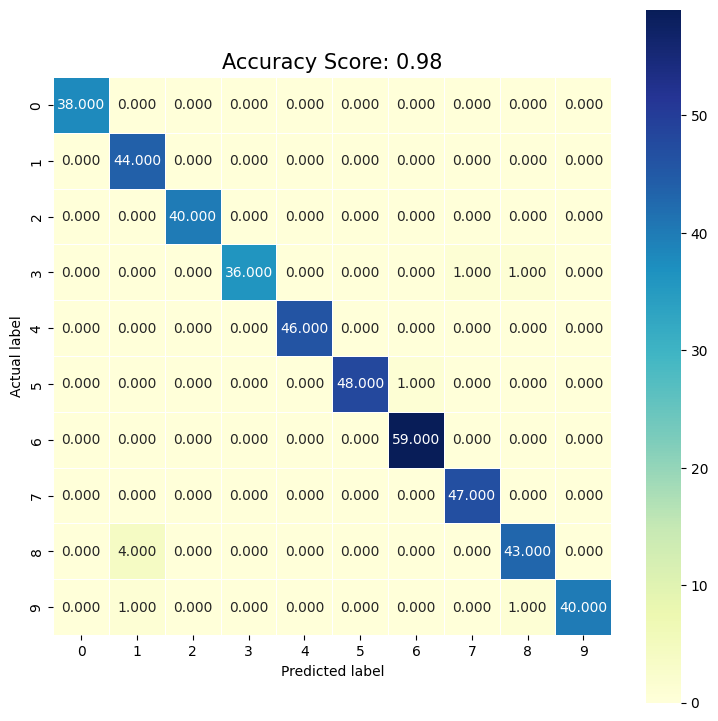

In [13]:
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5,square = True, cmap = 'YlGnBu')
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size = 15);

# Example III: Classifying Wines

In [14]:
from sklearn.datasets import load_wine
from sklearn.pipeline import make_pipeline

wine = load_wine()                                   # 178 wines, 13 features, 3 classes
X_w, y_w = wine.data, wine.target

# 75/25 split; stratify keeps the same class proportions in train and test
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_w, y_w, test_size=0.25, random_state=0, stratify=y_w)

# KNN on the raw features (no scaling)
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(Xw_train, yw_train)

# Same KNN, but scaling is done inside a pipeline
knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xw_train, yw_train)

print("Accuracy without scaling:", round(knn_raw.score(Xw_test, yw_test), 3))
print("Accuracy with scaling:   ", round(knn_scaled.score(Xw_test, yw_test), 3))

Accuracy without scaling: 0.667
Accuracy with scaling:    0.933


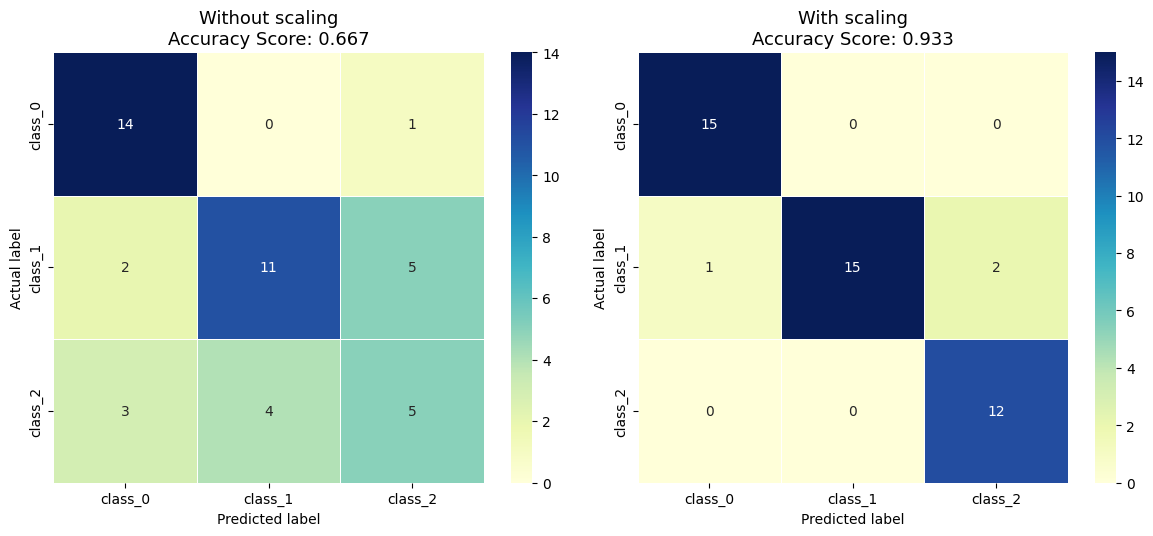

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {"Without scaling": knn_raw, "With scaling": knn_scaled}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, m) in zip(axes, models.items()):
    cm_w = confusion_matrix(yw_test, m.predict(Xw_test))   # rows = actual, columns = predicted
    score_w = m.score(Xw_test, yw_test)                    # accuracy on the test set

    sns.heatmap(cm_w, annot=True, fmt="d", linewidths=.5, square=True, cmap="YlGnBu",
                xticklabels=wine.target_names, yticklabels=wine.target_names, ax=ax)
    ax.set_ylabel("Actual label")
    ax.set_xlabel("Predicted label")
    ax.set_title("{0}\nAccuracy Score: {1:.3f}".format(name, score_w), size=13)

plt.tight_layout()
plt.show()